## Stroke Prediction ML (Sci-kit Learn Logistic Regression Model)

In [1]:
import pandas as pd

# Import Data
df = pd.read_csv('data/healthcare-dataset-stroke-data.csv')
df = df.drop(columns=['id'])
print(df.head())

   gender   age  hypertension  heart_disease ever_married      work_type  \
0    Male  67.0             0              1          Yes        Private   
1  Female  61.0             0              0          Yes  Self-employed   
2    Male  80.0             0              1          Yes        Private   
3  Female  49.0             0              0          Yes        Private   
4  Female  79.0             1              0          Yes  Self-employed   

  Residence_type  avg_glucose_level   bmi   smoking_status  stroke  
0          Urban             228.69  36.6  formerly smoked       1  
1          Rural             202.21   NaN     never smoked       1  
2          Rural             105.92  32.5     never smoked       1  
3          Urban             171.23  34.4           smokes       1  
4          Rural             174.12  24.0     never smoked       1  


### Data Visualization

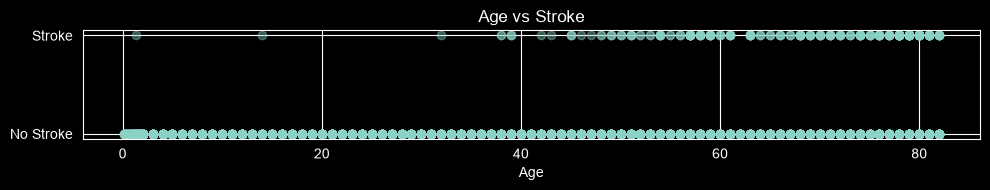

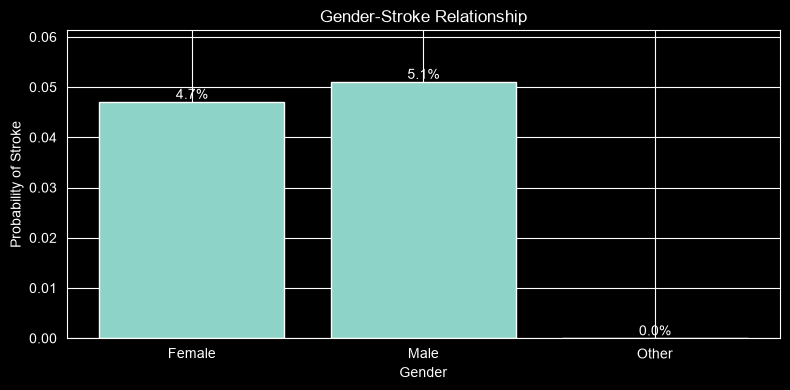

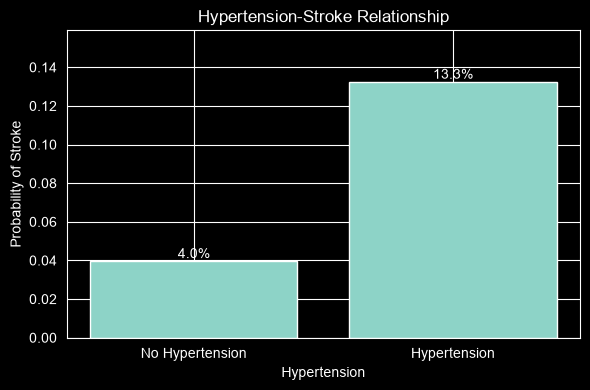

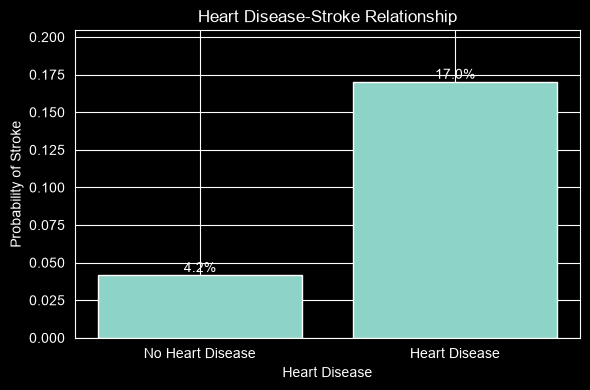

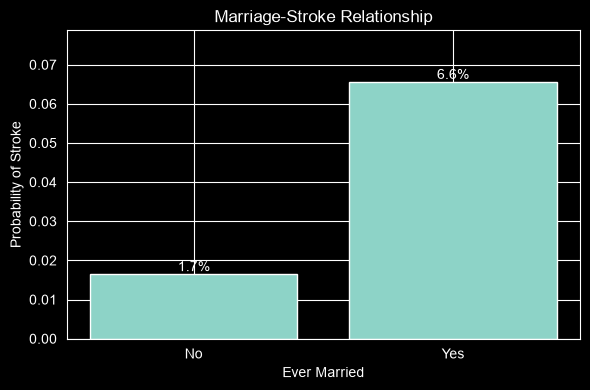

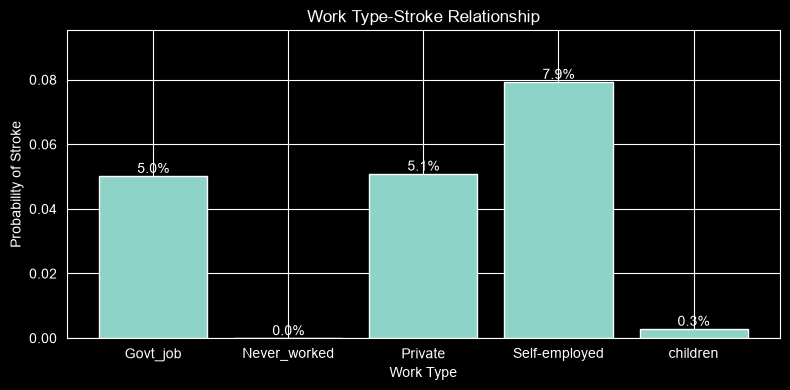

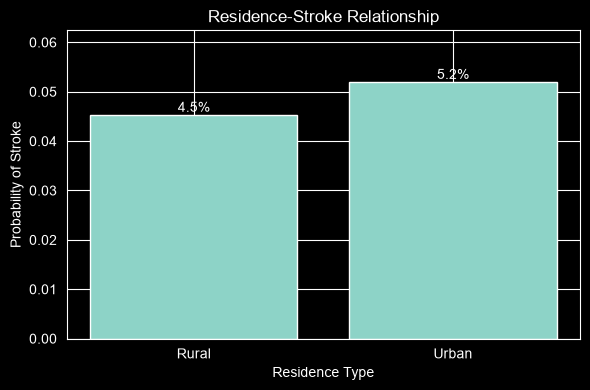

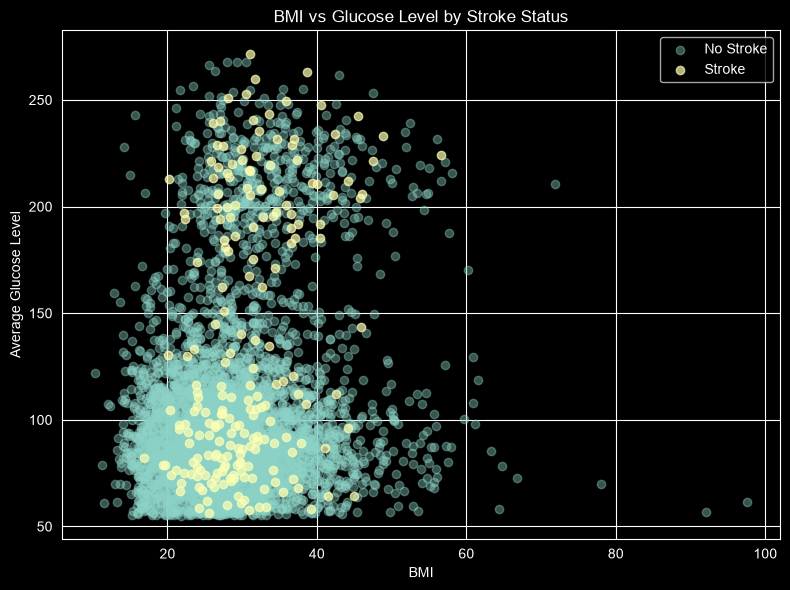

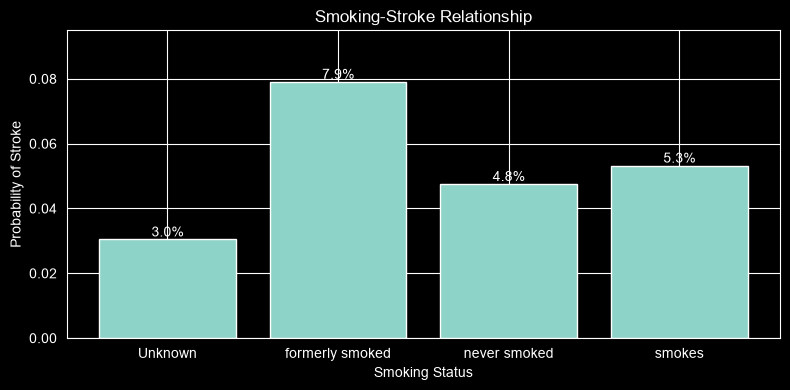

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Age-Stroke Relationship
fig1, ax1 = plt.subplots(figsize=(10, 2))

ax1.scatter(df["age"], df["stroke"], alpha=0.4)

ax1.set_yticks([0, 1])
ax1.set_yticklabels(["No Stroke", "Stroke"])
ax1.set_xlabel("Age")
ax1.set_title("Age vs Stroke")

plt.tight_layout()


# Gender-Stroke Relationship
fig2, ax2 = plt.subplots(figsize=(8, 4))

gender_stroke = df.groupby("gender")["stroke"].mean()

bars = ax2.bar(gender_stroke.index, gender_stroke)

ax2.set_xlabel("Gender")
ax2.set_ylabel("Probability of Stroke")
ax2.set_title("Gender-Stroke Relationship")
ax2.set_ylim(0, max(gender_stroke) * 1.2)

for bar, probability in zip(bars, gender_stroke):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{probability:.1%}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()


# Hypertension-Stroke Relationship
fig3, ax3 = plt.subplots(figsize=(6, 4))

hypertension_stroke = df.groupby("hypertension")["stroke"].mean()

bars = ax3.bar(
    ["No Hypertension", "Hypertension"],
    hypertension_stroke
)

ax3.set_xlabel("Hypertension")
ax3.set_ylabel("Probability of Stroke")
ax3.set_title("Hypertension-Stroke Relationship")
ax3.set_ylim(0, max(hypertension_stroke) * 1.2)

for bar, probability in zip(bars, hypertension_stroke):
    ax3.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{probability:.1%}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()


# Heart Disease-Stroke Relationship
fig4, ax4 = plt.subplots(figsize=(6, 4))

heart_disease_stroke = df.groupby("heart_disease")["stroke"].mean()

bars = ax4.bar(
    ["No Heart Disease", "Heart Disease"],
    heart_disease_stroke
)

ax4.set_xlabel("Heart Disease")
ax4.set_ylabel("Probability of Stroke")
ax4.set_title("Heart Disease-Stroke Relationship")
ax4.set_ylim(0, max(heart_disease_stroke) * 1.2)

for bar, probability in zip(bars, heart_disease_stroke):
    ax4.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{probability:.1%}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()


# Marriage-Stroke Relationship
fig5, ax5 = plt.subplots(figsize=(6, 4))

marriage_stroke = df.groupby("ever_married")["stroke"].mean()

bars = ax5.bar(
    marriage_stroke.index,
    marriage_stroke
)

ax5.set_xlabel("Ever Married")
ax5.set_ylabel("Probability of Stroke")
ax5.set_title("Marriage-Stroke Relationship")
ax5.set_ylim(0, max(marriage_stroke) * 1.2)

for bar, probability in zip(bars, marriage_stroke):
    ax5.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{probability:.1%}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()


# Work-Stroke Relationship
fig6, ax6 = plt.subplots(figsize=(8, 4))

work_stroke = df.groupby("work_type")["stroke"].mean()

bars = ax6.bar(
    work_stroke.index,
    work_stroke
)

ax6.set_xlabel("Work Type")
ax6.set_ylabel("Probability of Stroke")
ax6.set_title("Work Type-Stroke Relationship")
ax6.set_ylim(0, max(work_stroke) * 1.2)

for bar, probability in zip(bars, work_stroke):
    ax6.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{probability:.1%}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()


# Residence-Stroke Relationship
fig7, ax7 = plt.subplots(figsize=(6, 4))

residence_stroke = df.groupby("Residence_type")["stroke"].mean()

bars = ax7.bar(
    residence_stroke.index,
    residence_stroke
)

ax7.set_xlabel("Residence Type")
ax7.set_ylabel("Probability of Stroke")
ax7.set_title("Residence-Stroke Relationship")
ax7.set_ylim(0, max(residence_stroke) * 1.2)

for bar, probability in zip(bars, residence_stroke):
    ax7.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{probability:.1%}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()


# BMI/Glucose-Stroke Relationship
fig8, ax8 = plt.subplots(figsize=(8, 6))

no_stroke = df[df["stroke"] == 0]
stroke = df[df["stroke"] == 1]

ax8.scatter(
    no_stroke["bmi"],
    no_stroke["avg_glucose_level"],
    label="No Stroke",
    alpha=0.4
)

ax8.scatter(
    stroke["bmi"],
    stroke["avg_glucose_level"],
    label="Stroke",
    alpha=0.7
)

ax8.set_xlabel("BMI")
ax8.set_ylabel("Average Glucose Level")
ax8.set_title("BMI vs Glucose Level by Stroke Status")
ax8.legend()

plt.tight_layout()


# Smoking-Stroke Relationship
fig9, ax9 = plt.subplots(figsize=(8, 4))

smoking_stroke = df.groupby("smoking_status")["stroke"].mean()

bars = ax9.bar(
    smoking_stroke.index,
    smoking_stroke
)

ax9.set_xlabel("Smoking Status")
ax9.set_ylabel("Probability of Stroke")
ax9.set_title("Smoking-Stroke Relationship")
ax9.set_ylim(0, max(smoking_stroke) * 1.2)

for bar, probability in zip(bars, smoking_stroke):
    ax9.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{probability:.1%}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()


plt.show()

### Data Processing

In [3]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 1

# Create features X and target y.
X = df.copy()

# Drop missing values
X = X.replace("N/A", pd.NA).dropna()
print(f"{df.shape[0] - X.shape[0]} rows dropped")

# Create target Y
y = X["stroke"]  # Stroke occurrence (0 or 1)
X = X.drop(columns=["stroke"])  # Drop the target column from features

# Split the dataset into training (80%) and testing (20%) sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)


from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_cols = X_train.select_dtypes(exclude="str").columns.tolist()
categorical_cols = X_train.select_dtypes(include="str").columns.tolist()

print(f"Numeric columns: {numeric_cols}")
print(f"Categorical columns: {categorical_cols}")

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Diagnosing Warning for unknown catagories
# train_genders = set(X_train["gender"].unique())
# test_genders = set(X_test["gender"].unique())
# print("In test but not train:", test_genders - train_genders)

print(X_train_processed[:5])

201 rows dropped
Numeric columns: ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']
Categorical columns: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
[[-0.22539017 -0.32348315 -0.22920042  1.01727733 -1.0703845   0.
   0.          1.          0.          1.          0.          0.
   1.          0.          1.          0.        ]
 [ 0.57556351 -0.32348315 -0.22920042 -0.95672421 -1.35204764  1.
   0.          1.          0.          1.          0.          0.
   0.          0.          1.          0.        ]
 [-1.07084128 -0.32348315 -0.22920042  0.299256    0.88845464  1.
   0.          0.          0.          1.          0.          0.
   0.          0.          0.          0.        ]
 [ 1.68799918 -0.32348315 -0.22920042 -1.07394309  0.60679149  0.
   0.          0.          0.          0.          1.          0.
   1.          0.          1.          0.        ]
 [-0.09189789 -0.32348315 -0.22920042  2.768875    0.79883455  0.
  

In [4]:
# View data
feature_names = preprocessor.get_feature_names_out()

X_train_df = pd.DataFrame(
    X_train_processed.toarray() if hasattr(X_train_processed, "toarray") else X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_train_df.head()

,num__age,num__hypertension,num__heart_disease,num__avg_glucose_level,num__bmi,cat__gender_Male,cat__gender_Other,cat__ever_married_Yes,cat__work_type_Never_worked,cat__work_type_Private,cat__work_type_Self-employed,cat__work_type_children,cat__Residence_type_Urban,cat__smoking_status_formerly smoked,cat__smoking_status_never smoked,cat__smoking_status_smokes
4412,-0.225390,-0.323483,-0.2292,1.017277,-1.070384,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4467,0.575564,-0.323483,-0.2292,-0.956724,-1.352048,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
926,-1.070841,-0.323483,-0.2292,0.299256,0.888455,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4954,1.687999,-0.323483,-0.2292,-1.073943,0.606791,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1233,-0.091898,-0.323483,-0.2292,2.768875,0.798835,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


### Predictions (woo hoo)

In [5]:
# Import LinearRegression.
from sklearn.linear_model import LogisticRegression

# Instantiate logistic regression model.
model = LogisticRegression()

# Fit the model to the training data.
model.fit(X_train_processed, y_train)

# y_pred = model.predict_proba(X_test_processed)

y_prob = model.predict_proba(X_test_processed)[:, 1]
y_pred = (y_prob >= 0.15).astype(int)

print(y_pred)

[0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 

### Eval (The moment of truth)

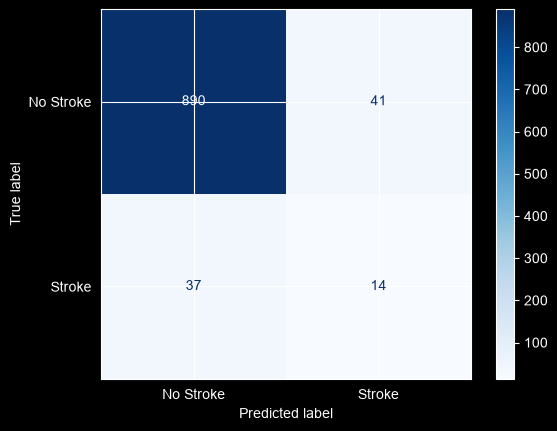

              precision    recall  f1-score   support

   No Stroke       0.96      0.96      0.96       931
      Stroke       0.25      0.27      0.26        51

    accuracy                           0.92       982
   macro avg       0.61      0.62      0.61       982
weighted avg       0.92      0.92      0.92       982



In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Stroke", "Stroke"])
disp.plot(cmap="Blues")
plt.show()

print(classification_report(y_test, y_pred, target_names=["No Stroke", "Stroke"]))


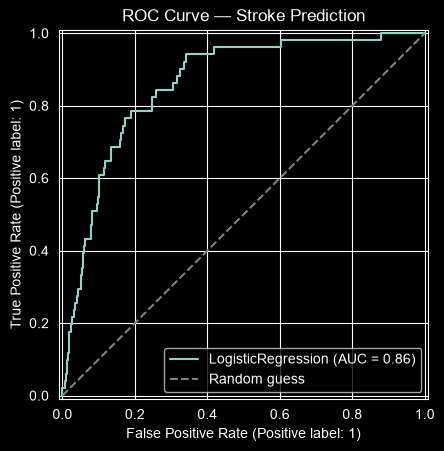

In [7]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(model, X_test_processed, y_test)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.title("ROC Curve — Stroke Prediction")
plt.legend()
plt.show()